# Model 2 — Similar Car Finder & Price Range Recommendation (kNN)

**Question:** Given my car's specifications, in which price range should I sell my car according to the top 10 cars in the dataset which are most similar to mine?

---

## Introduction

This notebook uses k-Nearest Neighbours (kNN) to find the 10 most similar cars to a query car in the dataset, then derives a recommended selling price range from the neighbours' prices.

**Key information:**

- **Algorithm:** You **must** use `NearestNeighbors` only. No other similarity or clustering algorithm is permitted.
- **Data:** Uses the **scaled** dataset for kNN distance computation (kNN is distance-based and requires scaled features). The unscaled dataset is also loaded to retrieve actual `Fiyat` values for display.
- The `Fiyat` column from the unscaled CSV is joined into the scaled dataframe by index for price lookups.

**What you can freely change:**
- Tune `n_neighbors`.
- Select different features (must come from the scaled dataset).

**What you cannot change:**
- The general technique category: this must remain a kNN-based similarity search.

## 1. Data Import

Load both the scaled dataset (for distance computation) and the unscaled dataset (to retrieve actual prices). **This cell is complete — do not modify it.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load scaled dataset for kNN distance computation
df_scaled = pd.read_csv('https://raw.githubusercontent.com/MamoMGD1/ISE302-DataMining-GroupProject/main/data/processed_dataset.csv')
# Load unscaled dataset to retrieve actual prices for display
df_unscaled = pd.read_csv('https://raw.githubusercontent.com/MamoMGD1/ISE302-DataMining-GroupProject/main/data/proceed_dataset_without_scaling.csv')

# Align the Fiyat column from unscaled data by index
df_scaled['Fiyat'] = df_unscaled['Fiyat']

print(f"Scaled dataset shape: {df_scaled.shape}")
df_scaled.head()

Scaled dataset shape: (2589, 88)


,Yıl,Kilometre,İlan Tarihi,Ortalama Kasko,Ortalama Trafik Sigortası,Üretim Yılı (İlk/Son),Silindir Sayısı,Koltuk Sayısı,Bagaj Hacmi,Yakıt Deposu,...,Uzunluk,Genişlik,Yükseklik,Ağırlık,Boş Ağırlığı,Aks Aralığı,Jant Boyutu,log_Fiyat,Fiyat_original,Fiyat
0,1.388641,-1.289586,0.420748,0.463442,0.364293,1.359964,-2.803043,-0.172722,0.549434,-0.653204,...,-0.102909,-0.293614,-0.469975,-0.809089,-0.747773,-0.159292,-0.442605,1.384169,2425000,2425000
1,1.388641,-1.178174,0.599267,0.994204,0.267896,1.367419,0.273294,-0.172722,0.828322,-0.384329,...,0.036678,0.975345,0.023313,-0.286926,-0.090398,0.014411,1.296250,1.820704,2900000,2900000
2,-0.529613,1.596267,0.040836,1.345487,-0.900493,-0.458785,0.273294,-0.172722,-0.735812,0.009815,...,-0.170805,-0.474894,-0.469975,-0.597253,-0.504301,-0.159292,1.296250,-0.436532,1150000,1150000
3,-0.721438,0.827446,-0.141989,0.961936,-0.900493,-0.458785,0.273294,-0.172722,-0.735812,0.009815,...,-0.170805,-0.474894,-0.469975,-0.184536,-0.036834,-0.159292,-0.442605,-0.252650,1240000,1240000
4,-1.296915,2.041960,-0.406661,0.203775,-0.594877,-1.269542,0.273294,-0.172722,-0.146060,0.855780,...,-0.463131,-1.079160,-0.117627,-0.508686,-0.299784,-0.306538,-1.312033,-1.683144,690000,690000


## 2. Feature Selection

Choose the features that will define "similarity" between cars. All features must come from the **scaled** dataset.

**TODO:** You may add, remove, or replace features from the recommended set below.

In [2]:
# TODO: Select your features. These must be from the SCALED dataset.
# Recommended starting set:
recommended_features = [
    'Yıl', 'Kilometre', 'Motor Hacmi', 'Motor Gücü', 'Vites Tipi',
    'Kasa Tipi_SUV', 'Kasa Tipi_Crossover',
    'Yakıt Tipi_Dizel', 'Yakıt Tipi_Hibrit',
    'paint_damage_score', 'total_changed_parts'
]
features = [f for f in recommended_features if f in df_scaled.columns]
X = df_scaled[features].fillna(0)
print(f"Feature matrix shape: {X.shape}")
print(f"Features used: {features}")

Feature matrix shape: (2589, 11)
Features used: ['Yıl', 'Kilometre', 'Motor Hacmi', 'Motor Gücü', 'Vites Tipi', 'Kasa Tipi_SUV', 'Kasa Tipi_Crossover', 'Yakıt Tipi_Dizel', 'Yakıt Tipi_Hibrit', 'paint_damage_score', 'total_changed_parts']


## 3. Fit the kNN Model

Fit a `NearestNeighbors` model on the full feature matrix. We use `n_neighbors=11` so that after excluding the query car itself (index 0 in the results), we are left with the 10 most similar cars.

**TODO:** You may adjust `n_neighbors` if you want more or fewer neighbours.

In [3]:
from sklearn.neighbors import NearestNeighbors

# TODO: Tune n_neighbors. 10 is recommended to find the 10 most similar cars.
knn = NearestNeighbors(n_neighbors=11, metric='euclidean')  # 11 to exclude the car itself
knn.fit(X)
print("kNN model fitted.")

kNN model fitted.


## 4. Query a Car — Find Its Nearest Neighbours

Select a row from the dataset as the query car and retrieve its 10 nearest neighbours.

**TODO:** Change `query_idx` to any row index you would like to use as the demo query car.

In [4]:
# TODO: Change query_idx to any row index you want to use as the demo query car.
query_idx = 42
query_car = X.iloc[[query_idx]]
distances, indices = knn.kneighbors(query_car)

# Exclude the query car itself (index 0)
neighbor_indices = indices[0][1:]
neighbor_distances = distances[0][1:]
print(f"Query car index: {query_idx}")
print(f"10 nearest neighbor indices: {neighbor_indices}")

Query car index: 42
10 nearest neighbor indices: [ 651 1003  215  648  662  497 1182  757  768  794]


## 5. Evaluation — Neighbour Table Display

Show the 10 nearest neighbours as a styled table with their key attributes and prices. Rows are ranked from most similar (rank 1) to least similar (rank 10).

> **⚠️ This cell displays placeholder neighbour data. Run after fitting the model and selecting a query car.**

In [5]:
# ⚠️ This cell displays placeholder neighbor data. Run after fitting the model and selecting a query car.
display_cols_unscaled = ['Yıl', 'Kilometre', 'Yakıt Tipi_Dizel', 'Yakıt Tipi_Hibrit',
                          'Kasa Tipi_SUV', 'paint_damage_score', 'Fiyat']
display_cols_available = [c for c in display_cols_unscaled if c in df_scaled.columns]

neighbors_df = df_scaled.iloc[neighbor_indices][display_cols_available].copy()
neighbors_df['kNN Distance'] = neighbor_distances
neighbors_df.index = range(1, 11)
neighbors_df.columns.name = 'Rank'
neighbors_df.style.format({'Fiyat': '{:,.0f} TL', 'kNN Distance': '{:.4f}'}).background_gradient(
    subset=['Fiyat'], cmap='Blues')

Rank,Yıl,Kilometre,Yakıt Tipi_Dizel,Yakıt Tipi_Hibrit,Kasa Tipi_SUV,paint_damage_score,Fiyat,kNN Distance
1,-1.296915,2.766212,1.016749,-0.184244,0.228060,1.949938,"635,000 TL",1.4409
2,-1.872391,3.657598,1.016749,-0.184244,0.228060,1.472680,"515,000 TL",1.8857
3,-2.064216,2.654788,1.016749,-0.184244,0.228060,2.714460,"530,000 TL",2.1634
4,-1.296915,1.997391,1.016749,-0.184244,0.228060,2.139341,"600,000 TL",2.2333
5,-1.296915,1.963964,1.016749,-0.184244,0.228060,1.156169,"678,000 TL",2.4652
6,-2.447867,2.966773,1.016749,-0.184244,0.228060,2.933110,"385,000 TL",2.5587
7,-1.296915,2.253664,1.016749,-0.184244,0.228060,0.172997,"530,000 TL",2.8254
8,-2.256042,3.624171,1.016749,-0.184244,0.228060,0.172997,"397,500 TL",2.8835
9,-0.337788,2.019675,1.016749,-0.184244,0.228060,1.156169,"795,000 TL",2.9115
10,-2.256042,1.763402,1.016749,-0.184244,0.228060,1.472680,"589,900 TL",3.0169


## 6. Visualization — Price Distribution Box Plot

Plot the distribution of prices across the 10 nearest neighbours. The red dot marks the query car's own price, providing a visual reference for whether it is priced above or below its peers.

> **⚠️ Replace neighbor_indices and query_idx with your actual outputs after fitting.**

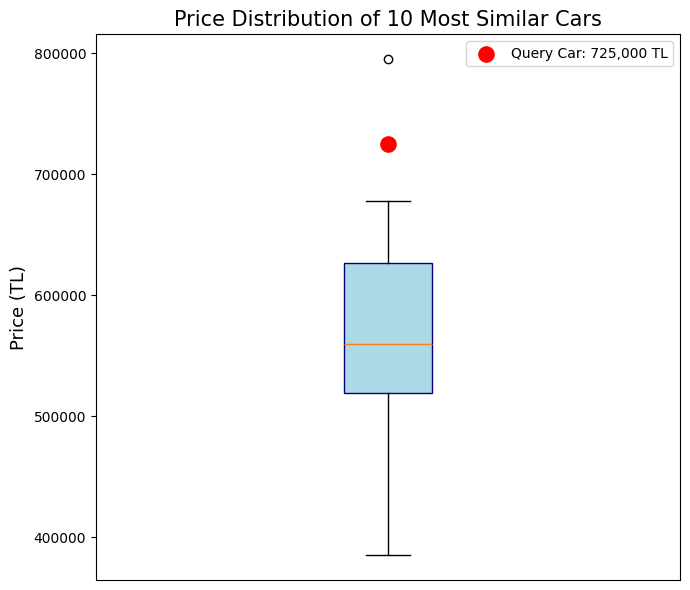

In [6]:
# ⚠️ Replace neighbor_indices and query_idx with your actual outputs after fitting.
neighbor_prices = df_scaled.iloc[neighbor_indices]['Fiyat'].values
query_price = df_scaled.iloc[query_idx]['Fiyat']

fig, ax = plt.subplots(figsize=(7, 6))
ax.boxplot(neighbor_prices, vert=True, patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='navy'))
ax.scatter([1], [query_price], color='red', zorder=5, s=120,
           label=f'Query Car: {query_price:,.0f} TL')
ax.set_ylabel('Price (TL)', fontsize=13)
ax.set_title('Price Distribution of 10 Most Similar Cars', fontsize=15)
ax.set_xticks([])
ax.legend()
plt.tight_layout()
plt.show()

## 7. Recommended Price Range

Derive a recommended selling price range using the median and IQR of the 10 neighbours' prices. The range `median ± IQR` captures the central spread of similar-car prices.

> **⚠️ Replace with your actual neighbor_prices after fitting.**

In [7]:
# ⚠️ Replace with your actual neighbor_prices after fitting.
median_price = np.median(neighbor_prices)
q1 = np.percentile(neighbor_prices, 25)
q3 = np.percentile(neighbor_prices, 75)
iqr = q3 - q1
lower_bound = median_price - iqr
upper_bound = median_price + iqr

print(f"Query car actual price: {query_price:,.0f} TL")
print(f"\n📊 Recommended Price Range (Median ± IQR):")
print(f"   Fair price range: {lower_bound:,.0f} TL — {upper_bound:,.0f} TL")
print(f"   Median of neighbors: {median_price:,.0f} TL")

Query car actual price: 725,000 TL

📊 Recommended Price Range (Median ± IQR):
   Fair price range: 452,450 TL — 667,450 TL
   Median of neighbors: 559,950 TL


## 8. Visualization — Similarity Distance Bar Chart

Plot the kNN distance score for each of the 10 nearest neighbours. Lower distance means greater similarity to the query car.

> **⚠️ Replace neighbor_distances and neighbor_indices with your actual outputs.**

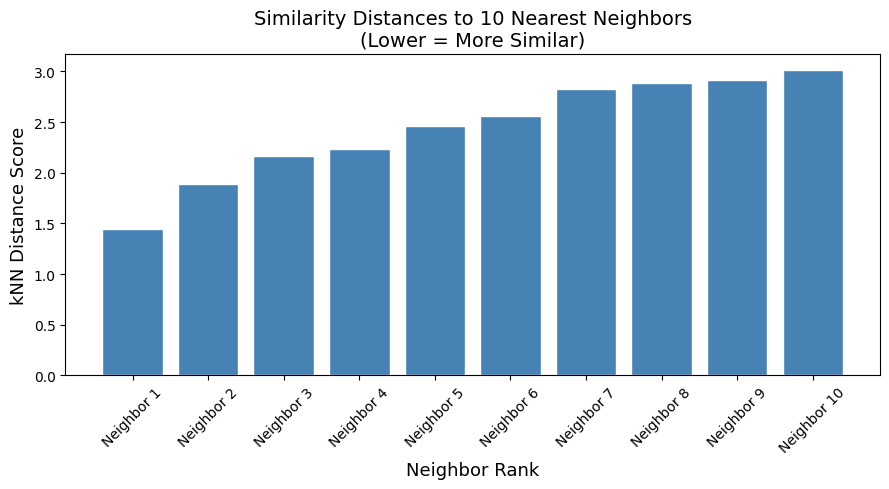

In [8]:
# ⚠️ Replace neighbor_distances and neighbor_indices with your actual outputs.
fig, ax = plt.subplots(figsize=(9, 5))
ranks = [f'Neighbor {i+1}' for i in range(len(neighbor_distances))]
bars = ax.bar(ranks, neighbor_distances, color='steelblue', edgecolor='white')
ax.set_xlabel('Neighbor Rank', fontsize=13)
ax.set_ylabel('kNN Distance Score', fontsize=13)
ax.set_title('Similarity Distances to 10 Nearest Neighbors\n(Lower = More Similar)', fontsize=14)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## ⚠️ If Your Model Underperforms

If your model produces poor results (e.g., the price range is extremely wide, neighbours appear visually unrelated, or the query car price lies far outside the recommended range), **do not discard your results**.

- Keep all outputs as-is.
- In your presentation, document exactly what you observe.
- Write a short hypothesis: Why might the model have produced unexpected results? (e.g., *"The feature set may not capture brand/model identity, causing luxury and economy cars to appear similar due to overlapping year and mileage values."*)